# Notebook 03 — Experimentos Deep Learning — Wavelet Fixo db2 (FordA)

Classificação binária com modelos DL usando coeficientes wavelet fixos (db2) como entrada multi-canal.
- **CNN + Wavelet**
- **LSTM + Wavelet**
- **CNN-LSTM + Wavelet**
- **Transformer + Wavelet**

**Pipeline:** Sinal → Wavelet db2 (approx + details como canais) → Grid Search → Avaliação

In [1]:
import os, sys
sys.path.append(".")
from config.experiment_config import (
    DATA_DIR, RESULTS_DIR, MODELS_DIR,
    DL_TRAINING_CONFIG, DL_MODELS_CONFIG, WAVELET_CONFIG,
    generate_dl_grid, SEED, GPU_ID, EPOCHS_OVERRIDE, MAX_GRID_CONFIGS,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import random
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
# Limitar a 1 GPU para evitar problemas de batch com MirroredStrategy
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.set_visible_devices([gpus[0]], 'GPU')
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponível: {tf.config.list_physical_devices('GPU')}")

from src.models import (
    create_cnn_model, create_lstm_model,
    create_cnn_lstm_model, create_transformer_model,
    get_callbacks, get_distribute_strategy,
)
from src.feature_extraction import WaveletFeatureExtractor
from src.evaluation import ClassificationEvaluator, ResultsManager
from src.visualization import ExperimentVisualizer

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

strategy = get_distribute_strategy()

DL_WAV_DIR = RESULTS_DIR / "dl_wavelet_experiments"
DL_WAV_DIR.mkdir(parents=True, exist_ok=True)

print(f"\nSEED={SEED}")
if GPU_ID: print(f"GPU selecionada: {GPU_ID}")
if EPOCHS_OVERRIDE: print(f"EPOCHS_OVERRIDE={EPOCHS_OVERRIDE}")
if MAX_GRID_CONFIGS: print(f"MAX_GRID_CONFIGS={MAX_GRID_CONFIGS}")

I0000 00:00:1773080000.224786 2327904 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.21.0
GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:2', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:3', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:4', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:5', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:6', device_type='GPU')]
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)


I0000 00:00:1773080002.142044 2327904 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12604 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


⚡ MirroredStrategy: 1 GPUs

SEED=42


## 1. Carregar e Transformar Dados

In [2]:
X_train_raw = np.load(DATA_DIR / "X_train.npy")
y_train = np.load(DATA_DIR / "y_train.npy")
X_val_raw = np.load(DATA_DIR / "X_val.npy")
y_val = np.load(DATA_DIR / "y_val.npy")
X_test_raw = np.load(DATA_DIR / "X_test.npy")
y_test = np.load(DATA_DIR / "y_test.npy")

print(f"Dados Raw:")
print(f"  Train: {X_train_raw.shape}, Val: {X_val_raw.shape}, Test: {X_test_raw.shape}")

Dados Raw:
  Train: (3060, 500), Val: (541, 500), Test: (1320, 500)


In [3]:
# Transformar para coeficientes wavelet multi-nível (como canais)
wfe = WaveletFeatureExtractor(
    wavelet=WAVELET_CONFIG["wavelet_type"],
    level=WAVELET_CONFIG["decomposition_level"],
    mode=WAVELET_CONFIG["mode"],
)

print(f"Wavelet: {WAVELET_CONFIG['wavelet_type']}, Níveis: {WAVELET_CONFIG['decomposition_level']}")
print("\nTransformando sinais para coeficientes wavelet...")
t0 = time.time()

X_train = wfe.get_multilevel_coefficients(X_train_raw, align_length=True)
X_val = wfe.get_multilevel_coefficients(X_val_raw, align_length=True)
X_test = wfe.get_multilevel_coefficients(X_test_raw, align_length=True)

print(f"  Tempo: {time.time()-t0:.2f}s")
print(f"\nDados Transformados (Wavelet Coefficients):")
print(f"  Train: {X_train.shape}  [samples, length, channels=níveis+1]")
print(f"  Val:   {X_val.shape}")
print(f"  Test:  {X_test.shape}")

channel_names = ["Approx"] + [f"Detail_{i}" for i in range(1, WAVELET_CONFIG["decomposition_level"]+1)]
print(f"  Canais: {channel_names}")

input_shape = X_train.shape[1:]
print(f"\nInput shape para modelos: {input_shape}")

Wavelet: db2, Níveis: 2

Transformando sinais para coeficientes wavelet...
  Tempo: 0.73s

Dados Transformados (Wavelet Coefficients):
  Train: (3060, 251, 3)  [samples, length, channels=níveis+1]
  Val:   (541, 251, 3)
  Test:  (1320, 251, 3)
  Canais: ['Approx', 'Detail_1', 'Detail_2']

Input shape para modelos: (251, 3)


## 2. Visualização dos Coeficientes Wavelet

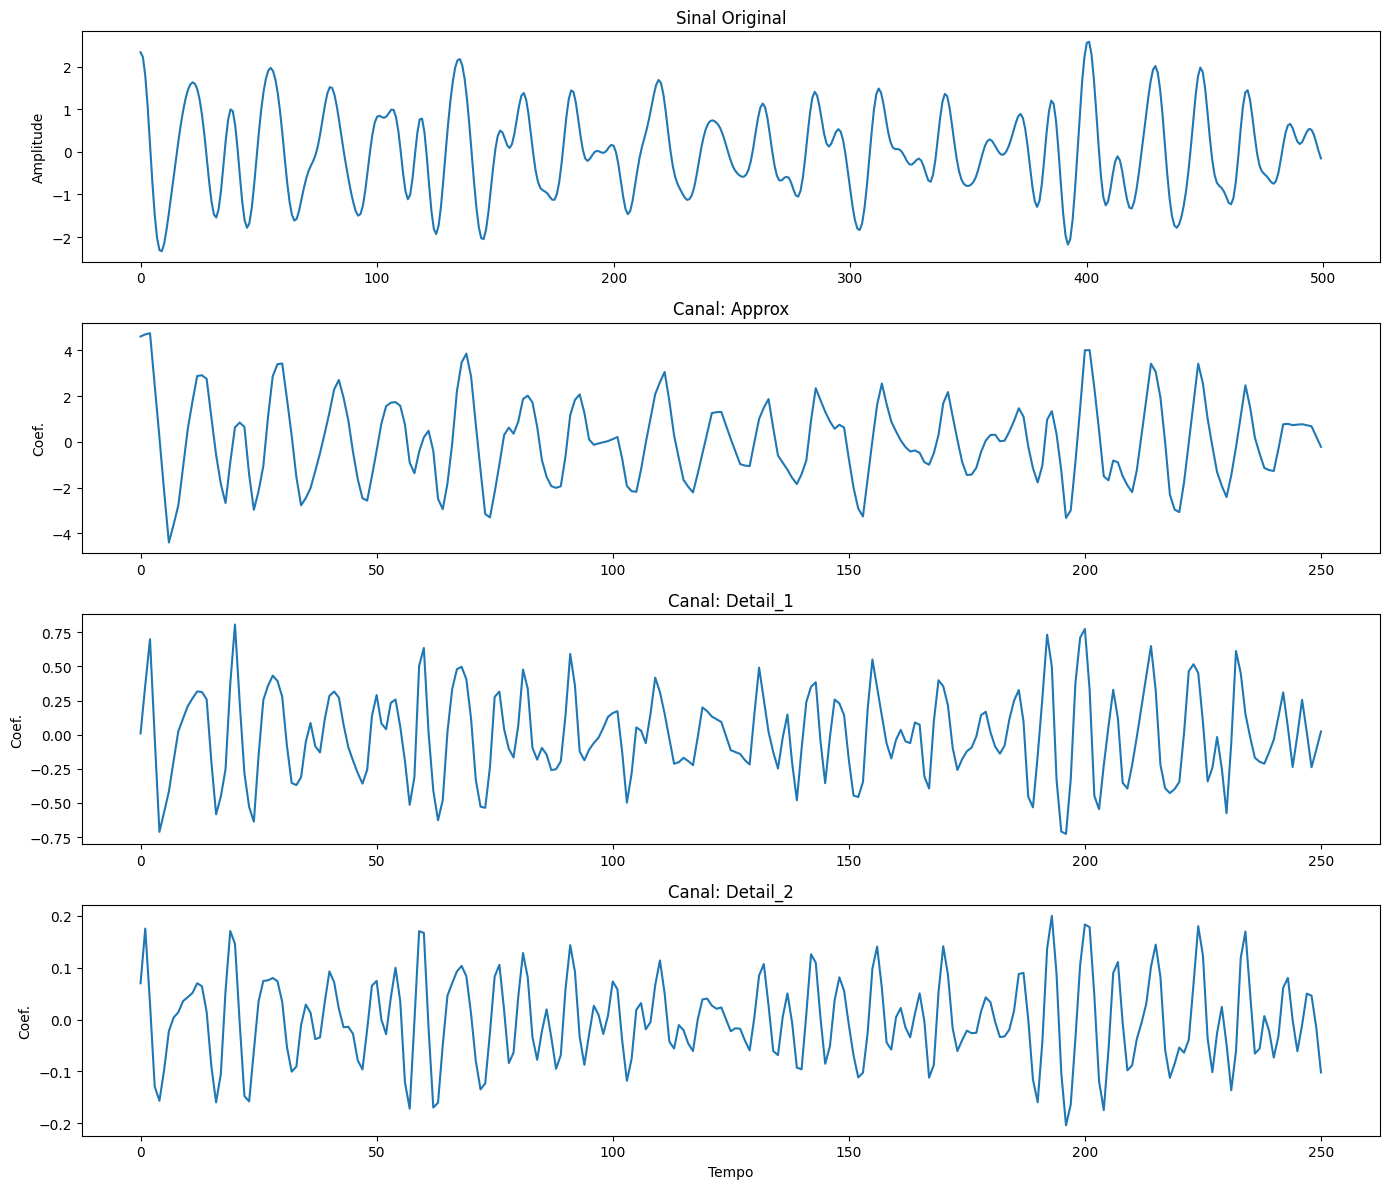

In [4]:
fig, axes = plt.subplots(len(channel_names) + 1, 1, figsize=(14, 3 * (len(channel_names) + 1)))
idx = 0

axes[0].plot(X_train_raw[idx])
axes[0].set_title("Sinal Original")
axes[0].set_ylabel("Amplitude")

for ch, name in enumerate(channel_names):
    axes[ch + 1].plot(X_train[idx, :, ch])
    axes[ch + 1].set_title(f"Canal: {name}")
    axes[ch + 1].set_ylabel("Coef.")

axes[-1].set_xlabel("Tempo")
plt.tight_layout()
plt.savefig(DL_WAV_DIR / "wavelet_channels_sample.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Configuração

In [5]:
results_manager = ResultsManager(DL_WAV_DIR)
evaluator = ClassificationEvaluator()
viz = ExperimentVisualizer()

training_config = DL_TRAINING_CONFIG.copy()
print("Configuração de Treinamento:")
for k, v in training_config.items():
    print(f"  {k}: {v}")

all_results = {}
all_histories = {}
all_grid_results = []

Configuração de Treinamento:
  epochs: 100
  batch_size: 64
  early_stopping_patience: 15
  reduce_lr_patience: 7
  reduce_lr_factor: 0.5
  min_lr: 1e-06
  verbose: 1


## 4. Experimento 1: CNN + Wavelet

In [6]:
print("=" * 70)
print("Grid Search: CNN com Wavelet db2")
print("=" * 70)

grid = generate_dl_grid("CNN")
base_params = DL_MODELS_CONFIG["CNN"].copy()
best_acc, best_key = 0.0, None

for gi, variation in enumerate(grid):
    params = {**base_params, **variation}
    run_name = f"Wav_CNN_g{gi}"
    print(f"\n--- [{gi+1}/{len(grid)}] {run_name}: {variation}")

    tf.keras.backend.clear_session()
    with strategy.scope():
        model = create_cnn_model(input_shape, params=params)

    model_path = str(MODELS_DIR / f"wav_cnn_g{gi}.keras")
    callbacks = get_callbacks(
        model_path,
        patience_early=training_config["early_stopping_patience"],
        patience_lr=training_config["reduce_lr_patience"],
        min_lr=training_config["min_lr"],
    )

    t0 = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=training_config["epochs"],
        batch_size=training_config["batch_size"],
        callbacks=callbacks, verbose=0,
    )
    elapsed = time.time() - t0

    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    metrics = evaluator.evaluate(y_test, y_pred, y_prob)

    print(f"    Acc={metrics['accuracy']:.4f}  F1={metrics['f1']:.4f}  "
          f"AUC={metrics['auc_roc']:.4f}  Time={elapsed:.1f}s")

    row = {"Model": "Wav_CNN", "grid_idx": gi, **variation,
           "Accuracy": metrics["accuracy"], "F1": metrics["f1"],
           "Precision": metrics["precision"], "Recall": metrics["recall"],
           "AUC_ROC": metrics["auc_roc"], "Params": model.count_params(),
           "Time (s)": round(elapsed, 1), "Epochs": len(history.history["loss"])}
    all_grid_results.append(row)

    if metrics["accuracy"] > best_acc:
        best_acc = metrics["accuracy"]
        best_key = run_name
        all_results["Wav_CNN"] = {
            "metrics": metrics, "time": elapsed,
            "epochs": len(history.history["loss"]),
            "y_pred": y_pred, "y_prob": y_prob,
            "params": model.count_params(),
            "best_variation": variation,
        }
        all_histories["Wav_CNN"] = history.history
        model.save(str(MODELS_DIR / "wav_cnn_best.keras"))

    results_manager.log_experiment("DL_Wavelet", run_name, metrics, {"params": params})

print(f"\nMelhor CNN: {best_key} — Acc={best_acc:.4f}")


Grid Search: CNN com Wavelet db2

--- [1/36] Wav_CNN_g0: {'dropout_rate': 0.2, 'l2_reg': 0.0001, 'filters': [32, 64, 128], 'kernel_sizes': [7, 5, 3]}
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).


I0000 00:00:1773080036.894094 2327904 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1773080038.058058 2328224 cuda_dnn.cc:461] Loaded cuDNN version 91900


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 36: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 37: early stopping
Restoring model weights from the end of the best epoch: 22.
    Acc=0.9402  F1=0.9387  AUC=0.9877  Time=30.8s

--- [2/36] Wav_CNN_g1: {'dropout_rate': 0.2, 'l2_reg': 0.0001, 'filter

## 5. Experimento 2: LSTM + Wavelet

In [7]:
print("=" * 70)
print("Grid Search: LSTM com Wavelet db2")
print("=" * 70)

grid = generate_dl_grid("LSTM")
base_params = DL_MODELS_CONFIG["LSTM"].copy()
best_acc, best_key = 0.0, None

for gi, variation in enumerate(grid):
    params = {**base_params, **variation}
    run_name = f"Wav_LSTM_g{gi}"
    print(f"\n--- [{gi+1}/{len(grid)}] {run_name}: {variation}")

    tf.keras.backend.clear_session()
    with strategy.scope():
        model = create_lstm_model(input_shape, params=params)

    model_path = str(MODELS_DIR / f"wav_lstm_g{gi}.keras")
    callbacks = get_callbacks(
        model_path,
        patience_early=training_config["early_stopping_patience"],
        patience_lr=training_config["reduce_lr_patience"],
        min_lr=training_config["min_lr"],
    )

    t0 = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=training_config["epochs"],
        batch_size=training_config["batch_size"],
        callbacks=callbacks, verbose=0,
    )
    elapsed = time.time() - t0

    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    metrics = evaluator.evaluate(y_test, y_pred, y_prob)

    print(f"    Acc={metrics['accuracy']:.4f}  F1={metrics['f1']:.4f}  "
          f"AUC={metrics['auc_roc']:.4f}  Time={elapsed:.1f}s")

    row = {"Model": "Wav_LSTM", "grid_idx": gi, **variation,
           "Accuracy": metrics["accuracy"], "F1": metrics["f1"],
           "Precision": metrics["precision"], "Recall": metrics["recall"],
           "AUC_ROC": metrics["auc_roc"], "Params": model.count_params(),
           "Time (s)": round(elapsed, 1), "Epochs": len(history.history["loss"])}
    all_grid_results.append(row)

    if metrics["accuracy"] > best_acc:
        best_acc = metrics["accuracy"]
        best_key = run_name
        all_results["Wav_LSTM"] = {
            "metrics": metrics, "time": elapsed,
            "epochs": len(history.history["loss"]),
            "y_pred": y_pred, "y_prob": y_prob,
            "params": model.count_params(),
            "best_variation": variation,
        }
        all_histories["Wav_LSTM"] = history.history
        model.save(str(MODELS_DIR / "wav_lstm_best.keras"))

    results_manager.log_experiment("DL_Wavelet", run_name, metrics, {"params": params})

print(f"\nMelhor LSTM: {best_key} — Acc={best_acc:.4f}")


Grid Search: LSTM com Wavelet db2

--- [1/18] Wav_LSTM_g0: {'dropout_rate': 0.2, 'l2_reg': 0.0001, 'units': [64, 32]}

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 32: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 39: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 40: early stopping
Restoring model weights from the end of the best epoch: 25.
    Acc=0.6659  F1=0.7413  AUC=0.7112  Time=60.7s

--- [2/18] Wav_LSTM_g1: {'dropout_rate': 0.2, 'l2_reg': 0.0001, 'units': [128, 64]}

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 22: early stopping
Restoring model weights from the end of the best epoch: 7.
    Acc=0.6992  F1=0.7523  AUC=0.7174  Time=32.7s

--- [3/18] Wav_LSTM_g2: {'dropout_rate': 0.2, 'l2_reg': 0.001, 'units': [64, 32]}

Epoch 21: ReduceLROnPlateau reducing learning rate to 

## 6. Experimento 3: CNN_LSTM + Wavelet

In [8]:
print("=" * 70)
print("Grid Search: CNN_LSTM com Wavelet db2")
print("=" * 70)

grid = generate_dl_grid("CNN_LSTM")
base_params = DL_MODELS_CONFIG["CNN_LSTM"].copy()
best_acc, best_key = 0.0, None

for gi, variation in enumerate(grid):
    params = {**base_params, **variation}
    run_name = f"Wav_CNN_LSTM_g{gi}"
    print(f"\n--- [{gi+1}/{len(grid)}] {run_name}: {variation}")

    tf.keras.backend.clear_session()
    with strategy.scope():
        model = create_cnn_lstm_model(input_shape, params=params)

    model_path = str(MODELS_DIR / f"wav_cnn_lstm_g{gi}.keras")
    callbacks = get_callbacks(
        model_path,
        patience_early=training_config["early_stopping_patience"],
        patience_lr=training_config["reduce_lr_patience"],
        min_lr=training_config["min_lr"],
    )

    t0 = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=training_config["epochs"],
        batch_size=training_config["batch_size"],
        callbacks=callbacks, verbose=0,
    )
    elapsed = time.time() - t0

    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    metrics = evaluator.evaluate(y_test, y_pred, y_prob)

    print(f"    Acc={metrics['accuracy']:.4f}  F1={metrics['f1']:.4f}  "
          f"AUC={metrics['auc_roc']:.4f}  Time={elapsed:.1f}s")

    row = {"Model": "Wav_CNN_LSTM", "grid_idx": gi, **variation,
           "Accuracy": metrics["accuracy"], "F1": metrics["f1"],
           "Precision": metrics["precision"], "Recall": metrics["recall"],
           "AUC_ROC": metrics["auc_roc"], "Params": model.count_params(),
           "Time (s)": round(elapsed, 1), "Epochs": len(history.history["loss"])}
    all_grid_results.append(row)

    if metrics["accuracy"] > best_acc:
        best_acc = metrics["accuracy"]
        best_key = run_name
        all_results["Wav_CNN_LSTM"] = {
            "metrics": metrics, "time": elapsed,
            "epochs": len(history.history["loss"]),
            "y_pred": y_pred, "y_prob": y_prob,
            "params": model.count_params(),
            "best_variation": variation,
        }
        all_histories["Wav_CNN_LSTM"] = history.history
        model.save(str(MODELS_DIR / "wav_cnn_lstm_best.keras"))

    results_manager.log_experiment("DL_Wavelet", run_name, metrics, {"params": params})

print(f"\nMelhor CNN_LSTM: {best_key} — Acc={best_acc:.4f}")


Grid Search: CNN_LSTM com Wavelet db2

--- [1/36] Wav_CNN_LSTM_g0: {'dropout_rate': 0.2, 'l2_reg': 0.0001, 'cnn_filters': [32, 64], 'lstm_units': [64, 32]}

Epoch 39: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 51: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 58: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 59: early stopping
Restoring model weights from the end of the best epoch: 44.
    Acc=0.9432  F1=0.9417  AUC=0.9869  Time=59.3s

--- [2/36] Wav_CNN_LSTM_g1: {'dropout_rate': 0.2, 'l2_reg': 0.0001, 'cnn_filters': [32, 64], 'lstm_units': [100, 50]}

Epoch 37: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 48: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 55: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 56: early stopping
Restoring model weights from the end of the best epoch: 41.
    Acc=0.9424  F1=0.9420  AUC=0.9868

## 7. Experimento 4: Transformer + Wavelet

In [9]:
print("=" * 70)
print("Grid Search: Transformer com Wavelet db2")
print("=" * 70)

grid = generate_dl_grid("Transformer")
base_params = DL_MODELS_CONFIG["Transformer"].copy()
best_acc, best_key = 0.0, None

for gi, variation in enumerate(grid):
    params = {**base_params, **variation}
    run_name = f"Wav_Transformer_g{gi}"
    print(f"\n--- [{gi+1}/{len(grid)}] {run_name}: {variation}")

    tf.keras.backend.clear_session()
    with strategy.scope():
        model = create_transformer_model(input_shape, params=params)

    model_path = str(MODELS_DIR / f"wav_transformer_g{gi}.keras")
    # Transformer usa WarmupSchedule, incompatível com ReduceLROnPlateau
    callbacks = get_callbacks(
        model_path,
        patience_early=training_config["early_stopping_patience"],
        use_reduce_lr=False,
    )

    t0 = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=training_config["epochs"],
        batch_size=training_config["batch_size"],
        callbacks=callbacks, verbose=0,
    )
    elapsed = time.time() - t0

    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    metrics = evaluator.evaluate(y_test, y_pred, y_prob)

    print(f"    Acc={metrics['accuracy']:.4f}  F1={metrics['f1']:.4f}  "
          f"AUC={metrics['auc_roc']:.4f}  Time={elapsed:.1f}s")

    row = {"Model": "Wav_Transformer", "grid_idx": gi, **variation,
           "Accuracy": metrics["accuracy"], "F1": metrics["f1"],
           "Precision": metrics["precision"], "Recall": metrics["recall"],
           "AUC_ROC": metrics["auc_roc"], "Params": model.count_params(),
           "Time (s)": round(elapsed, 1), "Epochs": len(history.history["loss"])}
    all_grid_results.append(row)

    if metrics["accuracy"] > best_acc:
        best_acc = metrics["accuracy"]
        best_key = run_name
        all_results["Wav_Transformer"] = {
            "metrics": metrics, "time": elapsed,
            "epochs": len(history.history["loss"]),
            "y_pred": y_pred, "y_prob": y_prob,
            "params": model.count_params(),
            "best_variation": variation,
        }
        all_histories["Wav_Transformer"] = history.history
        model.save(str(MODELS_DIR / "wav_transformer_best.keras"))

    results_manager.log_experiment("DL_Wavelet", run_name, metrics, {"params": params})

print(f"\nMelhor Transformer: {best_key} — Acc={best_acc:.4f}")

Grid Search: Transformer com Wavelet db2

--- [1/48] Wav_Transformer_g0: {'dropout_rate': 0.15, 'num_heads': 2, 'ff_dim': 64, 'num_transformer_blocks': 2, 'l2_reg': 0.0001}
Epoch 45: early stopping
Restoring model weights from the end of the best epoch: 30.
    Acc=0.5159  F1=0.0000  AUC=0.5000  Time=50.0s

--- [2/48] Wav_Transformer_g1: {'dropout_rate': 0.15, 'num_heads': 2, 'ff_dim': 64, 'num_transformer_blocks': 2, 'l2_reg': 0.001}
Epoch 43: early stopping
Restoring model weights from the end of the best epoch: 28.
    Acc=0.5159  F1=0.0000  AUC=0.5000  Time=47.1s

--- [3/48] Wav_Transformer_g2: {'dropout_rate': 0.15, 'num_heads': 2, 'ff_dim': 64, 'num_transformer_blocks': 3, 'l2_reg': 0.0001}
Epoch 49: early stopping
Restoring model weights from the end of the best epoch: 34.
    Acc=0.5159  F1=0.0000  AUC=0.5000  Time=66.7s

--- [4/48] Wav_Transformer_g3: {'dropout_rate': 0.15, 'num_heads': 2, 'ff_dim': 64, 'num_transformer_blocks': 3, 'l2_reg': 0.001}
Epoch 37: early stopping
Res

## 8. Comparação dos Resultados

In [10]:
comp_rows = []
for name, info in all_results.items():
    row = {"Model": name, **info["metrics"],
           "Params": info["params"], "Time (s)": round(info["time"], 1),
           "Epochs": info["epochs"]}
    comp_rows.append(row)

comparison_df = pd.DataFrame(comp_rows).sort_values("accuracy", ascending=False)
comparison_df = comparison_df.set_index("Model")
print("\n" + "=" * 80)
print("COMPARAÇÃO DOS MODELOS DL (Wavelet db2)")
print("=" * 80)
print(comparison_df.to_string())

comparison_df.to_csv(DL_WAV_DIR / "comparison_dl_wavelet.csv")
pd.DataFrame(all_grid_results).to_csv(DL_WAV_DIR / "all_grid_results_dl_wavelet.csv", index=False)
print(f"\nResultados salvos em {DL_WAV_DIR}")


COMPARAÇÃO DOS MODELOS DL (Wavelet db2)
                 accuracy        f1  precision    recall   auc_roc  log_loss  specificity  Params  Time (s)  Epochs
Model                                                                                                              
Wav_CNN          0.956061  0.955039   0.946237  0.964006  0.988986  0.162966     0.948605  184065      52.1      70
Wav_CNN_LSTM     0.951515  0.950000   0.948518  0.951487  0.987616  0.148129     0.951542   54721      92.6      93
Wav_LSTM         0.705303  0.757934   0.629132  0.953052  0.709322  0.561837     0.472834   32001      59.4      39
Wav_Transformer  0.515909  0.000000   0.000000  0.000000  0.500000  0.692665     1.000000  191617      50.0      45

Resultados salvos em /home/felipeteodoro/projetos/LearnableWaveletLayer/tests/ford-a/results/dl_wavelet_experiments


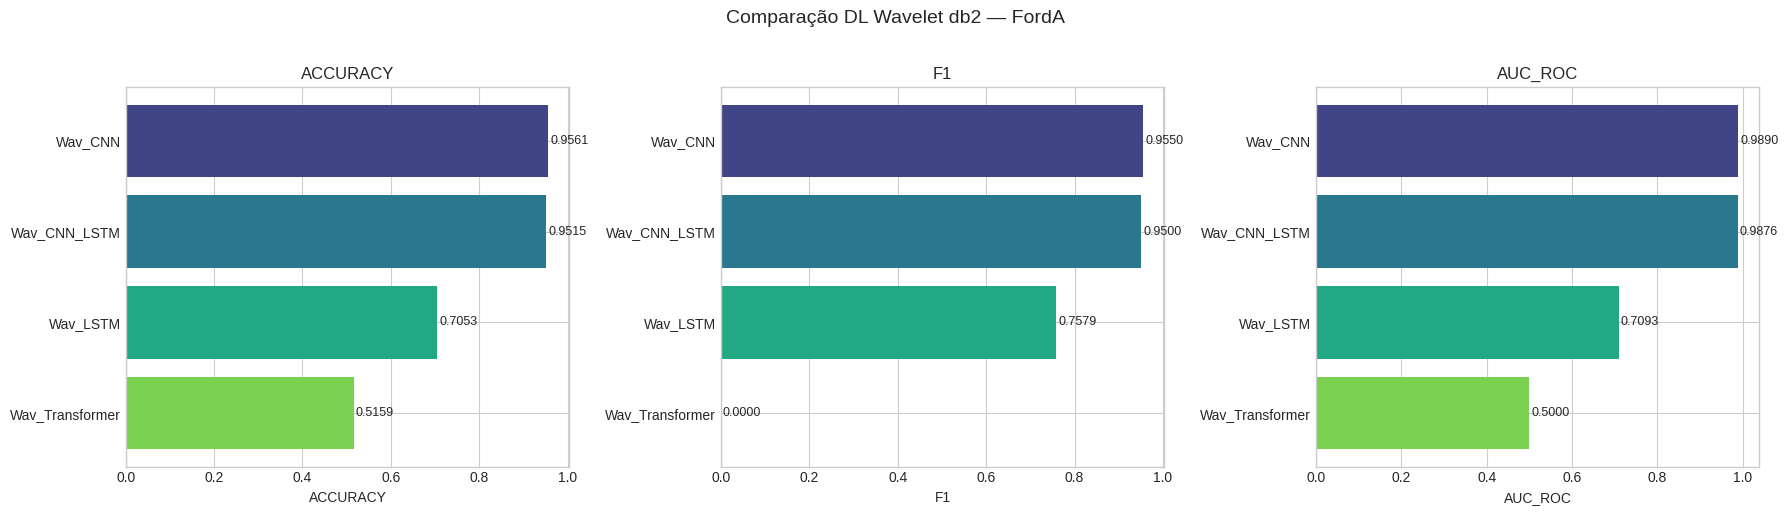

In [11]:
metrics_to_plot = ["accuracy", "f1", "auc_roc"]
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(6 * len(metrics_to_plot), 5))
model_names = comparison_df.index.tolist()
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(model_names)))

for ax, metric in zip(axes, metrics_to_plot):
    values = comparison_df[metric].values
    bars = ax.barh(range(len(model_names)), values, color=colors)
    ax.set_yticks(range(len(model_names)))
    ax.set_yticklabels(model_names)
    ax.set_xlabel(metric.upper())
    ax.set_title(metric.upper())
    ax.invert_yaxis()
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=9)
fig.suptitle("Comparação DL Wavelet db2 — FordA", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(DL_WAV_DIR / "comparison_chart_dl_wavelet.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Evolução do Treinamento

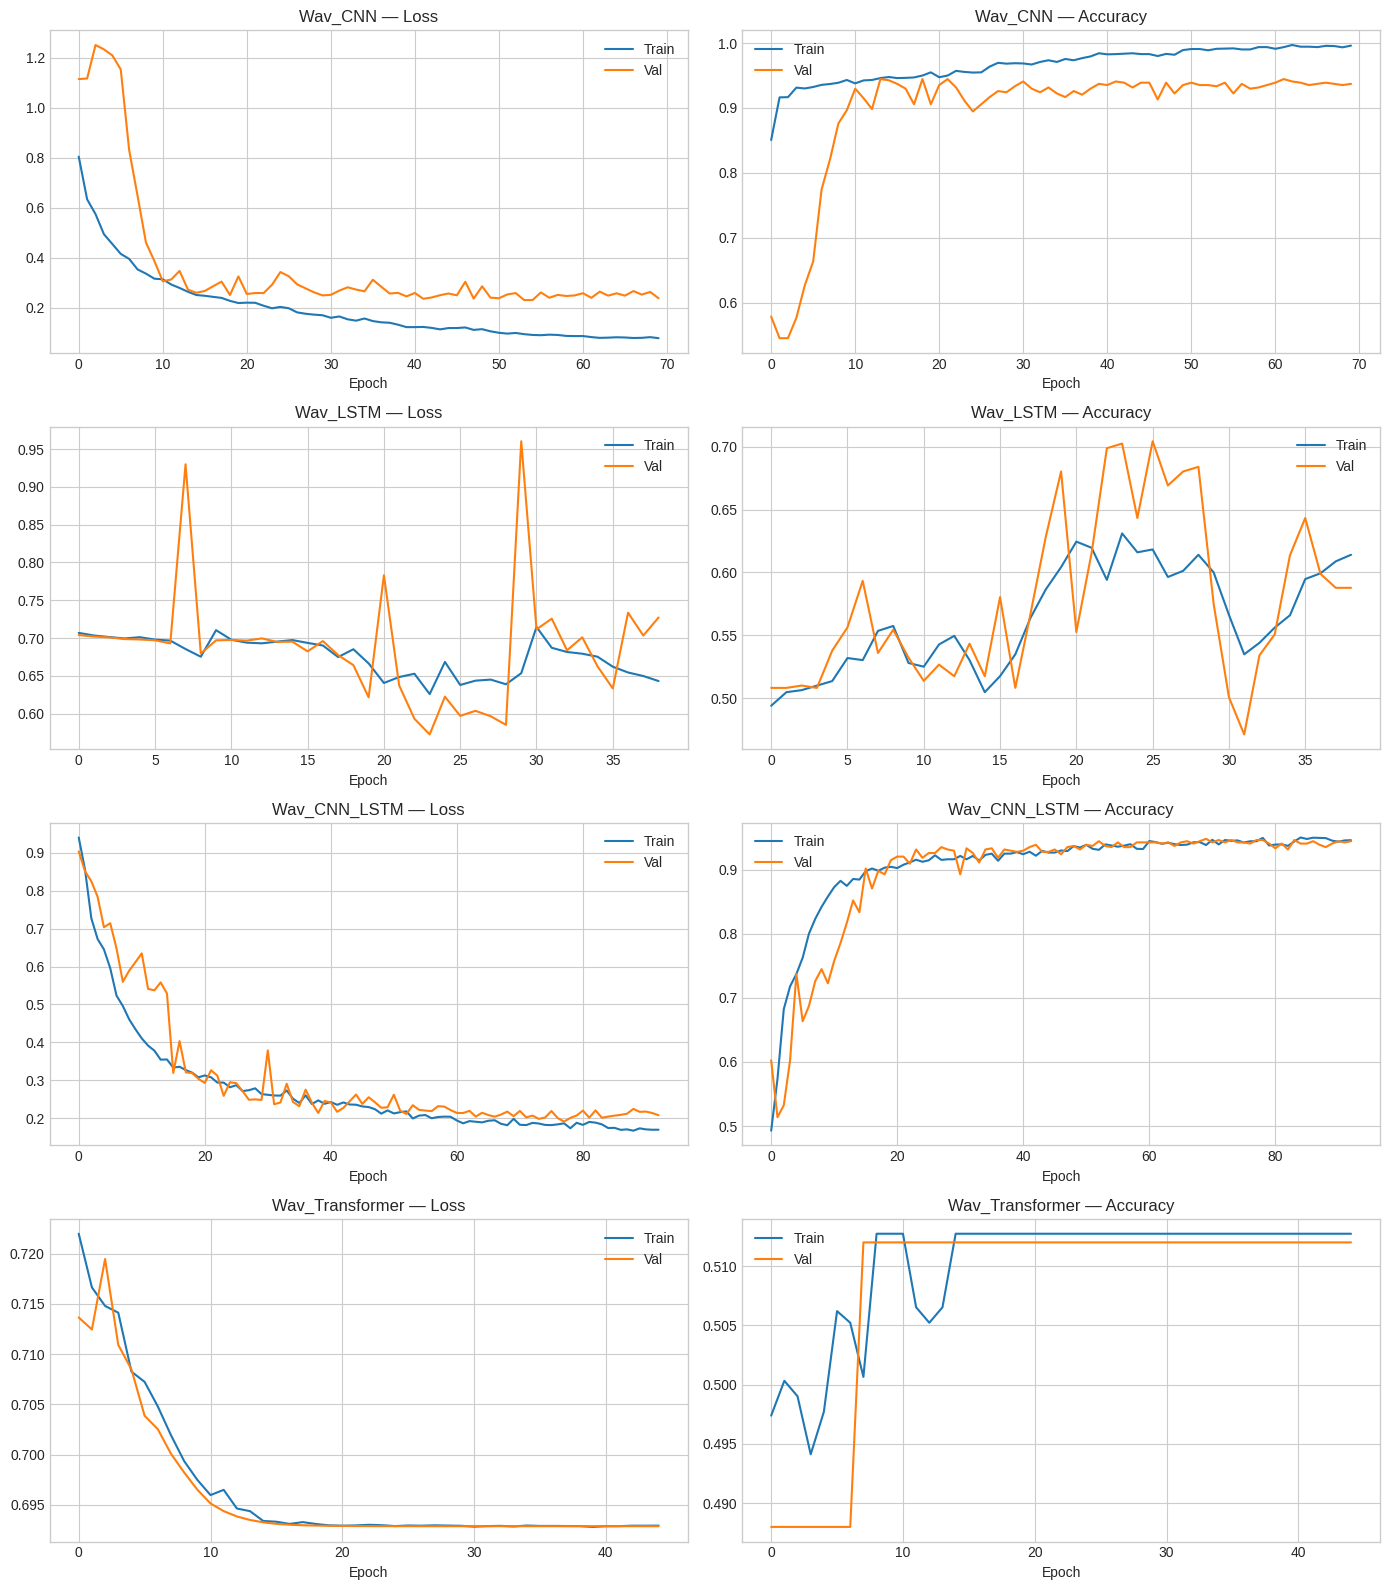

In [12]:
n_models = len(all_histories)
if n_models > 0:
    fig, axes = plt.subplots(n_models, 2, figsize=(14, 4 * n_models))
    if n_models == 1:
        axes = axes.reshape(1, -1)
    for i, (name, hist) in enumerate(all_histories.items()):
        axes[i, 0].plot(hist["loss"], label="Train")
        axes[i, 0].plot(hist["val_loss"], label="Val")
        axes[i, 0].set_title(f"{name} — Loss")
        axes[i, 0].set_xlabel("Epoch")
        axes[i, 0].legend()
        acc_key = "accuracy" if "accuracy" in hist else "acc"
        val_acc_key = "val_accuracy" if "val_accuracy" in hist else "val_acc"
        if acc_key in hist:
            axes[i, 1].plot(hist[acc_key], label="Train")
            axes[i, 1].plot(hist[val_acc_key], label="Val")
            axes[i, 1].set_title(f"{name} — Accuracy")
            axes[i, 1].set_xlabel("Epoch")
            axes[i, 1].legend()
    plt.tight_layout()
    plt.savefig(DL_WAV_DIR / "training_evolution_dl_wavelet.png", dpi=150, bbox_inches="tight")
    plt.show()

## 10. Confusion Matrices e ROC

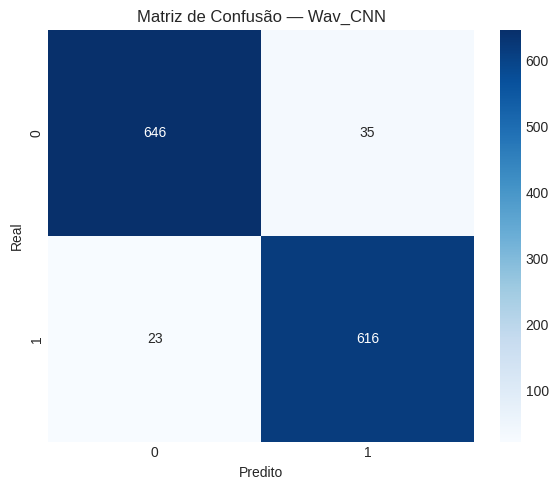

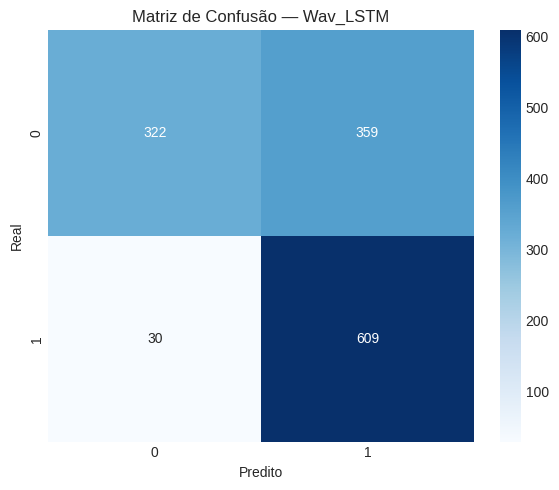

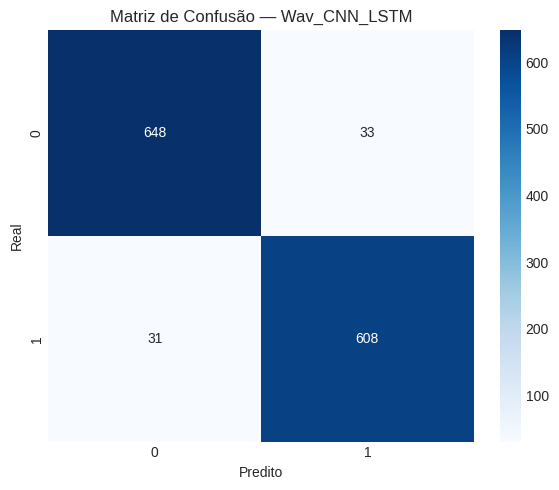

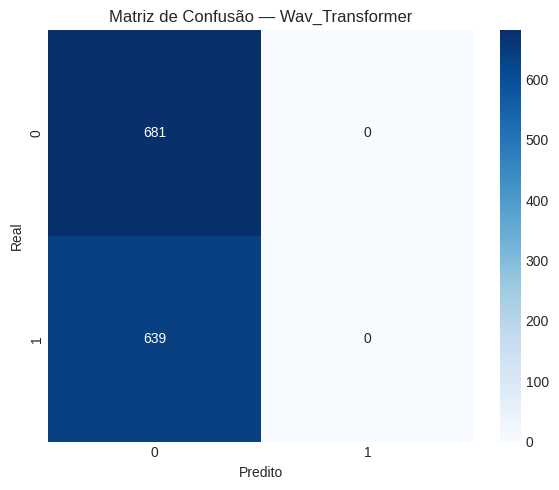

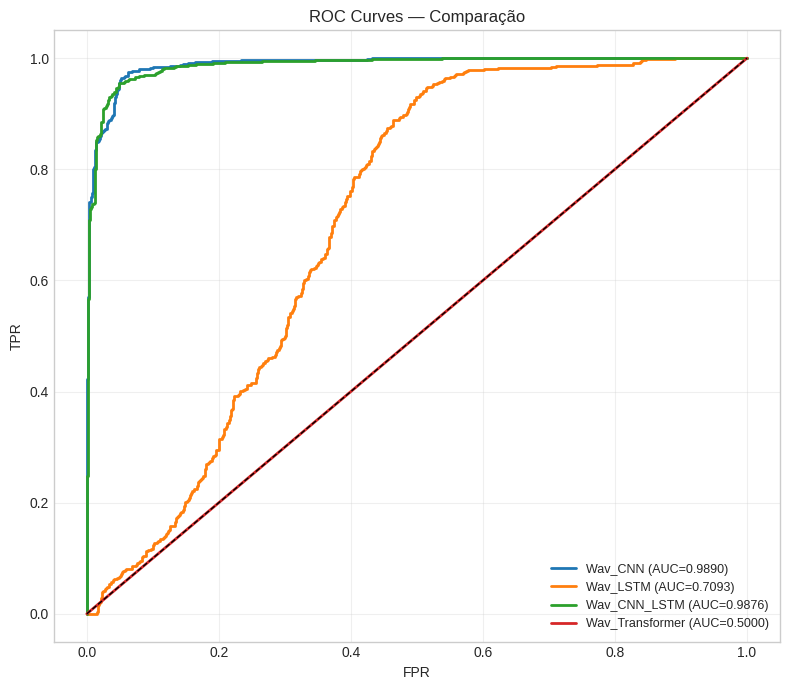

In [13]:
from sklearn.metrics import roc_curve, auc

for name, info in all_results.items():
    viz.plot_confusion_matrix(
        y_test, info["y_pred"],
        model_name=name,
        save_path=DL_WAV_DIR / f"confusion_matrix_{name}.png",
    )
    plt.show()

roc_data = {}
for name, info in all_results.items():
    if "y_prob" in info:
        fpr, tpr, _ = roc_curve(y_test, info["y_prob"])
        auc_val = auc(fpr, tpr)
        roc_data[name] = (fpr, tpr, auc_val)
if roc_data:
    viz.plot_multi_roc(
        roc_data,
        save_path=DL_WAV_DIR / "roc_curves_dl_wavelet.png",
    )
    plt.show()

## 11. Resumo

In [14]:
print("=" * 60)
print("RESUMO — DL Wavelet db2 Experiments (FordA)")
print("=" * 60)
print(f"Wavelet: {WAVELET_CONFIG['wavelet_type']}, Níveis: {WAVELET_CONFIG['decomposition_level']}")
print(f"Input shape: {input_shape}")
print(f"Arquiteturas avaliadas: {len(all_results)}")
print(f"Total de configurações grid: {len(all_grid_results)}")
if all_results:
    best_name = comparison_df.index[0]
    print(f"Melhor modelo: {best_name}")
    print(f"  Accuracy: {comparison_df.loc[best_name, 'accuracy']:.4f}")
    print(f"  F1:       {comparison_df.loc[best_name, 'f1']:.4f}")
    print(f"  AUC-ROC:  {comparison_df.loc[best_name, 'auc_roc']:.4f}")
print(f"Resultados em: {DL_WAV_DIR}")

RESUMO — DL Wavelet db2 Experiments (FordA)
Wavelet: db2, Níveis: 2
Input shape: (251, 3)
Arquiteturas avaliadas: 4
Total de configurações grid: 138
Melhor modelo: Wav_CNN
  Accuracy: 0.9561
  F1:       0.9550
  AUC-ROC:  0.9890
Resultados em: /home/felipeteodoro/projetos/LearnableWaveletLayer/tests/ford-a/results/dl_wavelet_experiments
